# RL Trading Agent — IEOR 198 Final Project

**Author:** Sophie Zhang
**Date:** Spring 2026

---

## Abstract

We implement a tabular Q-learning agent trained to make daily long/flat trading decisions on SPY (S&P 500 ETF) using three technical indicators — RSI, a moving average crossover signal, and 5-day momentum — as a discrete 18-state representation. The agent is trained on data from 2018–2022 and evaluated out-of-sample on 2023–2024. We find that a learning rate of α=0.01 yields the best generalization, achieving a Sharpe ratio of 0.856 and a total return of 21.52% on the test set. However, the agent does not outperform a passive buy-and-hold benchmark, which returned 58.82% with a Sharpe of 1.883 over the same period, primarily due to the strong bull market trend and the information loss inherent in a coarse discrete state space.

---

## 1. Introduction

Reinforcement Learning (RL) is a way to make decisions sequentially when outcomes and environments are uncertain, which fits trading well. Instead of learning from labeled data, an RL agent learns by trying actions and seeing the results to figure out what works. Q-learning, a basic RL method, learns how good different actions are (buy, hold, or sell) depending on the current situation, and uses that to decide further actions.

In this project, I trained a Q-learning model using past daily price data for SPY (an S&P 500 ETF). I used a few technical indicators to describe the market at each point in time, measuring success using daily returns. Finally, I tested how well the model performs on new data not seen during training.

---

## 2. Dataset

In [4]:
!python3 -m pip install yfinance pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 17.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 15.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 16.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 16.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 15.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [seaborn]4/16 [yfinance]]]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

TICKER      = 'SPY'
TRAIN_START = '2018-01-01'
TRAIN_END   = '2022-12-31'
TEST_START  = '2023-01-01'
TEST_END    = '2024-12-31'

raw = yf.download(TICKER, start=TRAIN_START, end=TEST_END, auto_adjust=True)
raw = raw[['Close']].copy()
raw.columns = ['close']
print(f"Downloaded {len(raw)} trading days for {TICKER}")
raw.tail()

[*********************100%***********************]  1 of 1 completed

Downloaded 1760 trading days for SPY


,close
Date,
2024-12-23,586.186584
2024-12-24,592.702148
2024-12-26,592.741577
2024-12-27,586.502075
2024-12-30,579.809143


## 3. Feature Engineering (State Space)

We construct three features that define the agent's *state* at each time step:

| Feature | Description |
|---|---|
| `rsi_bin` | 14-day RSI binned into 3 levels: oversold / neutral / overbought |
| `ma_signal` | 1 if 10-day SMA > 50-day SMA (uptrend), else 0 |
| `ret_bin` | 5-day return binned into 3 levels: negative / flat / positive |

This gives us a discrete state space of 3 × 2 × 3 = **18 states** — small enough for tabular Q-learning.

In [27]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df = raw.copy()

# raw features
df['rsi']    = compute_rsi(df['close'])
df['sma10']  = df['close'].rolling(10).mean()
df['sma50']  = df['close'].rolling(50).mean()
df['ret5']   = df['close'].pct_change(5)
df['ret1']   = df['close'].pct_change(1)   # used as reward

# discretised state features
df['rsi_bin']   = pd.cut(df['rsi'],   bins=[0, 35, 65, 100], labels=[0, 1, 2]).astype(float)
df['ma_signal'] = (df['sma10'] > df['sma50']).astype(int)
df['ret_bin']   = pd.cut(df['ret5'],  bins=[-np.inf, -0.01, 0.01, np.inf], labels=[0, 1, 2]).astype(float)

df.dropna(inplace=True)

# helper: encode (rsi_bin, ma_signal, ret_bin) → single integer state index
def encode_state(row):
    return int(row['rsi_bin']) * 6 + int(row['ma_signal']) * 3 + int(row['ret_bin'])

df['state'] = df.apply(encode_state, axis=1)

print(f"State space size: {df['state'].nunique()} unique states observed")
print(f"Total rows after feature engineering: {len(df)}")
df[['close','rsi','ma_signal','ret5','state']].head(10)

State space size: 17 unique states observed
Total rows after feature engineering: 1711


,close,rsi,ma_signal,ret5,state
Date,,,,,
2018-03-14,242.309723,57.506297,0,0.009239,7
2018-03-15,242.045547,50.506339,1,0.003283,10
2018-03-16,242.308075,44.945607,1,-0.012808,9
2018-03-19,239.029556,44.505041,1,-0.024942,9
2018-03-20,239.436035,50.813354,1,-0.016930,9
2018-03-21,238.976532,59.416222,1,-0.013756,9
2018-03-22,233.002777,41.514090,0,-0.037360,6
2018-03-23,228.036423,26.750703,0,-0.058899,0
2018-03-26,234.275314,40.301761,0,-0.019890,6


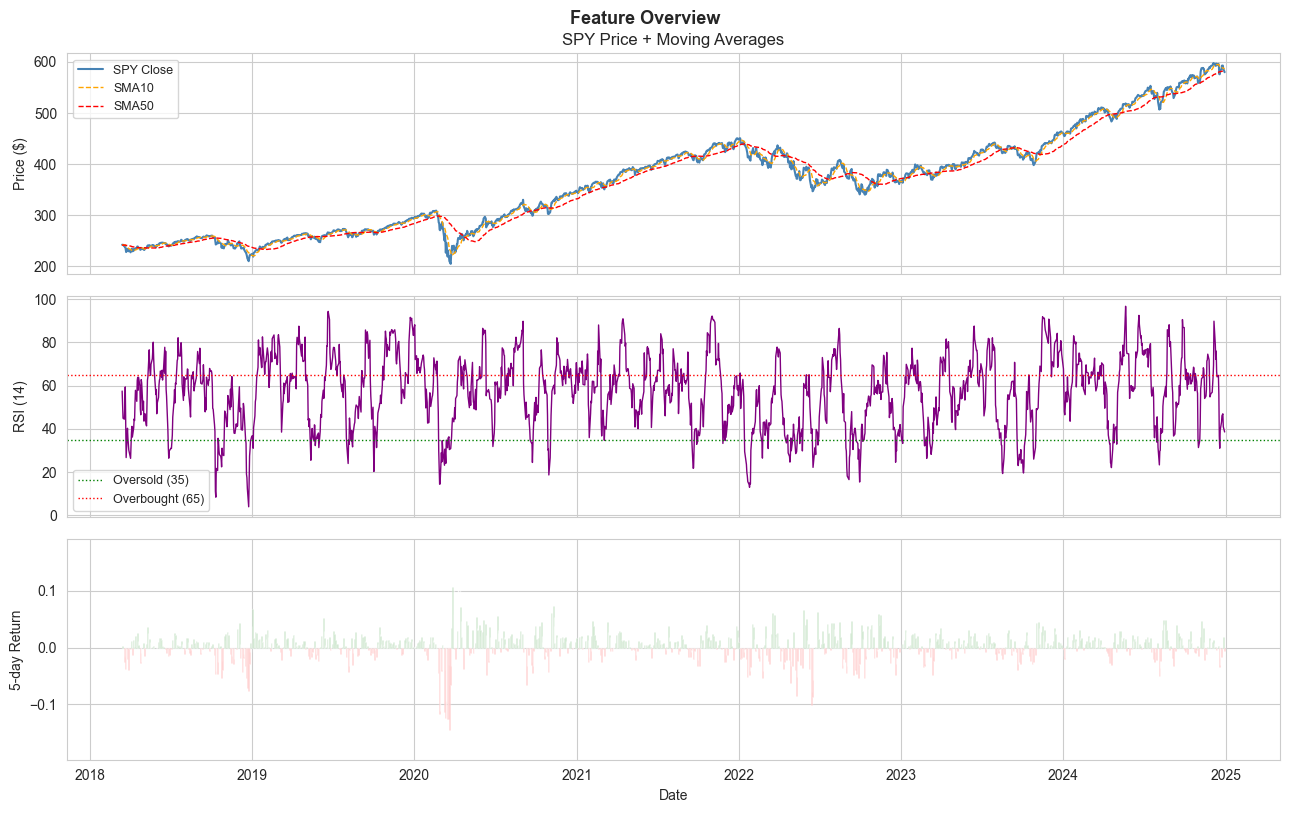

In [28]:
# quick visualisation of the features over time
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df['close'], color='steelblue', lw=1.5, label='SPY Close')
axes[0].plot(df.index, df['sma10'], color='orange', lw=1, linestyle='--', label='SMA10')
axes[0].plot(df.index, df['sma50'], color='red',    lw=1, linestyle='--', label='SMA50')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=9)
axes[0].set_title(f'{TICKER} Price + Moving Averages')

axes[1].plot(df.index, df['rsi'], color='purple', lw=1)
axes[1].axhline(35, color='green', linestyle=':', lw=1, label='Oversold (35)')
axes[1].axhline(65, color='red',   linestyle=':', lw=1, label='Overbought (65)')
axes[1].set_ylabel('RSI (14)')
axes[1].legend(fontsize=9)

axes[2].bar(df.index, df['ret5'], color=np.where(df['ret5'] >= 0, 'green', 'red'), alpha=0.5, width=1)
axes[2].set_ylabel('5-day Return')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.suptitle('Feature Overview', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('features_overview.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Methods — Q-Learning Agent

### 4.1 Q-Learning Background

Q-learning maintains a table $Q(s, a)$ representing the expected cumulative discounted reward of taking action $a$ in state $s$. At each step the agent:

1. Observes current state $s_t$
2. Chooses action $a_t$ via ε-greedy policy (explore with prob ε, exploit otherwise)
3. Receives reward $r_t$ (next-day return, adjusted for position)
4. Observes next state $s_{t+1}$
5. Updates the Q-table:

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]$$

**Actions:** 0 = Short (−1), 1 = Flat (0), 2 = Long (+1)  
**Reward:** `position × next_day_return` — so the agent is rewarded for being long in up-days and short in down-days.

In [15]:
# hyperparameters
ALPHA         = 0.1     # learning rate
GAMMA         = 0.99    # discount factor
EPSILON_START = 1.0     # initial exploration rate
EPSILON_END   = 0.05    # min exploration rate
EPSILON_DECAY = 0.995   # decay per episode
N_EPISODES    = 500     # training episodes (each = one pass through train data)
N_STATES      = 18      # 3 × 2 × 3
N_ACTIONS     = 3       # short, flat, long
POSITION_MAP  = {0: -1, 1: 0, 2: 1}   # action -> position
# ─────────────────────────────────────────────────────────────────────────────

# Train / test split
train_df = df.loc[TRAIN_START:TRAIN_END].copy()
test_df  = df.loc[TEST_START:TEST_END].copy()
print(f"Train: {len(train_df)} days | Test: {len(test_df)} days")

Train: 1210 days | Test: 501 days


In [16]:
np.random.seed(42)
Q = np.zeros((N_STATES, N_ACTIONS))

epsilon       = EPSILON_START
episode_returns = []

states  = train_df['state'].values
rewards_raw = train_df['ret1'].values   # next-day return

for episode in range(N_EPISODES):
    total_reward = 0.0

    for t in range(len(states) - 1):
        s  = states[t]
        s_ = states[t + 1]

        # ε-greedy action selection
        if np.random.rand() < epsilon:
            a = np.random.randint(N_ACTIONS)
        else:
            a = np.argmax(Q[s])

        position = POSITION_MAP[a]
        r = position * rewards_raw[t + 1]   # reward = position * tomorrow's return

        # Q-table update
        td_target = r + GAMMA * np.max(Q[s_])
        Q[s, a]  += ALPHA * (td_target - Q[s, a])

        total_reward += r

    episode_returns.append(total_reward)
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode+1:4d} | Cumulative reward: {total_reward:.4f} | ε: {epsilon:.3f}")

print("\nTraining complete!")
print("\nLearned Q-table:")
print(pd.DataFrame(Q, columns=['Short','Flat','Long']).round(4))

Episode  100 | Cumulative reward: -0.0529 | ε: 0.606
Episode  200 | Cumulative reward: 0.3062 | ε: 0.367
Episode  300 | Cumulative reward: 0.4579 | ε: 0.222
Episode  400 | Cumulative reward: 0.0845 | ε: 0.135
Episode  500 | Cumulative reward: 0.4093 | ε: 0.082

Training complete!

Learned Q-table:
     Short    Flat    Long
0   0.0390  0.0470  0.0545
1   0.0357  0.0468  0.0393
2   0.0423  0.0471  0.0431
3   0.0372  0.0407  0.0483
4   0.0540  0.0473  0.0381
5   0.0000  0.0000  0.0000
6   0.0410  0.0488  0.0373
7   0.0413  0.0440  0.0508
8   0.0422  0.0470  0.0402
9   0.0351  0.0391  0.0364
10  0.0354  0.0369  0.0338
11  0.0340  0.0355  0.0346
12  0.0000  0.0000  0.0000
13  0.0513  0.0418  0.0404
14  0.0490  0.0418  0.0397
15  0.0323  0.0361  0.0353
16  0.0347  0.0350  0.0345
17  0.0341  0.0349  0.0336


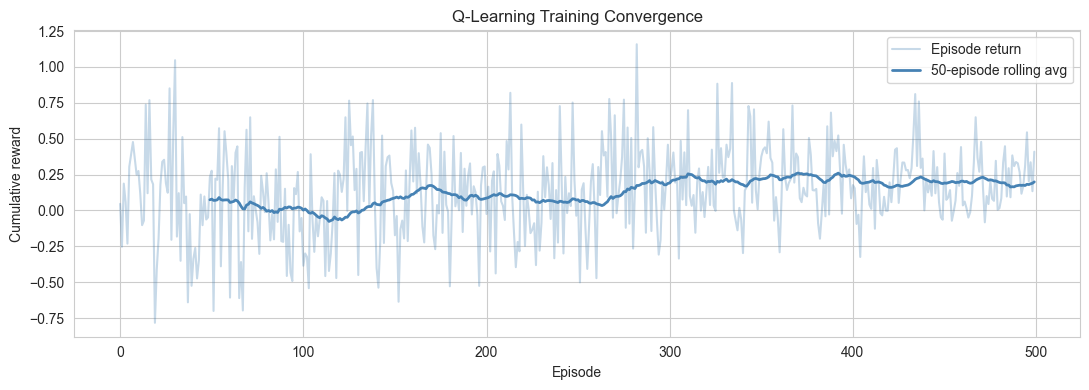

In [17]:
# plot training convergence
rolling_avg = pd.Series(episode_returns).rolling(50).mean()

plt.figure(figsize=(11, 4))
plt.plot(episode_returns, alpha=0.3, color='steelblue', label='Episode return')
plt.plot(rolling_avg,     color='steelblue', lw=2, label='50-episode rolling avg')
plt.xlabel('Episode')
plt.ylabel('Cumulative reward')
plt.title('Q-Learning Training Convergence')
plt.legend()
plt.tight_layout()
plt.savefig('training_convergence.png', dpi=120)
plt.show()

## 5. Results

### 5.1 Out-of-Sample Backtest (2023–2024)

We run the **greedy** policy (always pick argmax of Q) on the held-out test set and compare against buy-and-hold SPY.

In [18]:
def backtest(df_slice, Q, position_map):
    """Run greedy policy on df_slice, return a DataFrame with daily metrics."""
    states_  = df_slice['state'].values
    ret1_    = df_slice['ret1'].values
    dates_   = df_slice.index

    positions, strat_rets = [], []
    for t in range(len(states_) - 1):
        a   = np.argmax(Q[states_[t]])
        pos = position_map[a]
        r   = pos * ret1_[t + 1]
        positions.append(pos)
        strat_rets.append(r)

    result = pd.DataFrame({
        'date':       dates_[1:],
        'position':   positions,
        'strat_ret':  strat_rets,
        'bh_ret':     ret1_[1:],       # buy-and-hold daily return
    }).set_index('date')

    result['strat_cum'] = (1 + result['strat_ret']).cumprod()
    result['bh_cum']    = (1 + result['bh_ret']).cumprod()
    return result


train_bt = backtest(train_df, Q, POSITION_MAP)
test_bt  = backtest(test_df,  Q, POSITION_MAP)

print("Test set preview:")
test_bt.head()

Test set preview:


,position,strat_ret,bh_ret,strat_cum,bh_cum
date,,,,,
2023-01-04,0,0.0,0.007720,1.0,1.007720
2023-01-05,0,-0.0,-0.011413,1.0,0.996219
2023-01-06,0,0.0,0.022932,1.0,1.019064
2023-01-09,0,-0.0,-0.000567,1.0,1.018486
2023-01-10,0,0.0,0.007013,1.0,1.025629


In [19]:
def sharpe(returns, periods=252):
    """Annualized Sharpe ratio (assumes 0% risk-free rate)."""
    if returns.std() == 0:
        return 0.0
    return (returns.mean() / returns.std()) * np.sqrt(periods)

def max_drawdown(cum_returns):
    peak  = cum_returns.cummax()
    dd    = (cum_returns - peak) / peak
    return dd.min()

def print_stats(label, bt):
    total_ret_strat = bt['strat_cum'].iloc[-1] - 1
    total_ret_bh    = bt['bh_cum'].iloc[-1]    - 1
    sharpe_strat    = sharpe(bt['strat_ret'])
    sharpe_bh       = sharpe(bt['bh_ret'])
    mdd_strat       = max_drawdown(bt['strat_cum'])
    mdd_bh          = max_drawdown(bt['bh_cum'])
    n_trades        = (bt['position'].diff().abs() > 0).sum()

    print(f"\n{'='*50}")
    print(f" {label}")
    print(f"{'='*50}")
    print(f"{'Metric':<22} {'RL Agent':>12} {'Buy & Hold':>12}")
    print(f"{'-'*46}")
    print(f"{'Total Return':<22} {total_ret_strat:>11.2%} {total_ret_bh:>11.2%}")
    print(f"{'Sharpe Ratio':<22} {sharpe_strat:>12.3f} {sharpe_bh:>12.3f}")
    print(f"{'Max Drawdown':<22} {mdd_strat:>11.2%} {mdd_bh:>11.2%}")
    print(f"{'# Position Changes':<22} {n_trades:>12}")

print_stats('IN-SAMPLE (Train 2018–2022)',  train_bt)
print_stats('OUT-OF-SAMPLE (Test 2023–2024)', test_bt)


 IN-SAMPLE (Train 2018–2022)
Metric                     RL Agent   Buy & Hold
----------------------------------------------
Total Return                82.63%      51.30%
Sharpe Ratio                  0.980        0.508
Max Drawdown               -16.84%     -33.72%
# Position Changes              170

 OUT-OF-SAMPLE (Test 2023–2024)
Metric                     RL Agent   Buy & Hold
----------------------------------------------
Total Return                 8.30%      58.82%
Sharpe Ratio                  0.708        1.883
Max Drawdown                -4.96%      -9.97%
# Position Changes               48


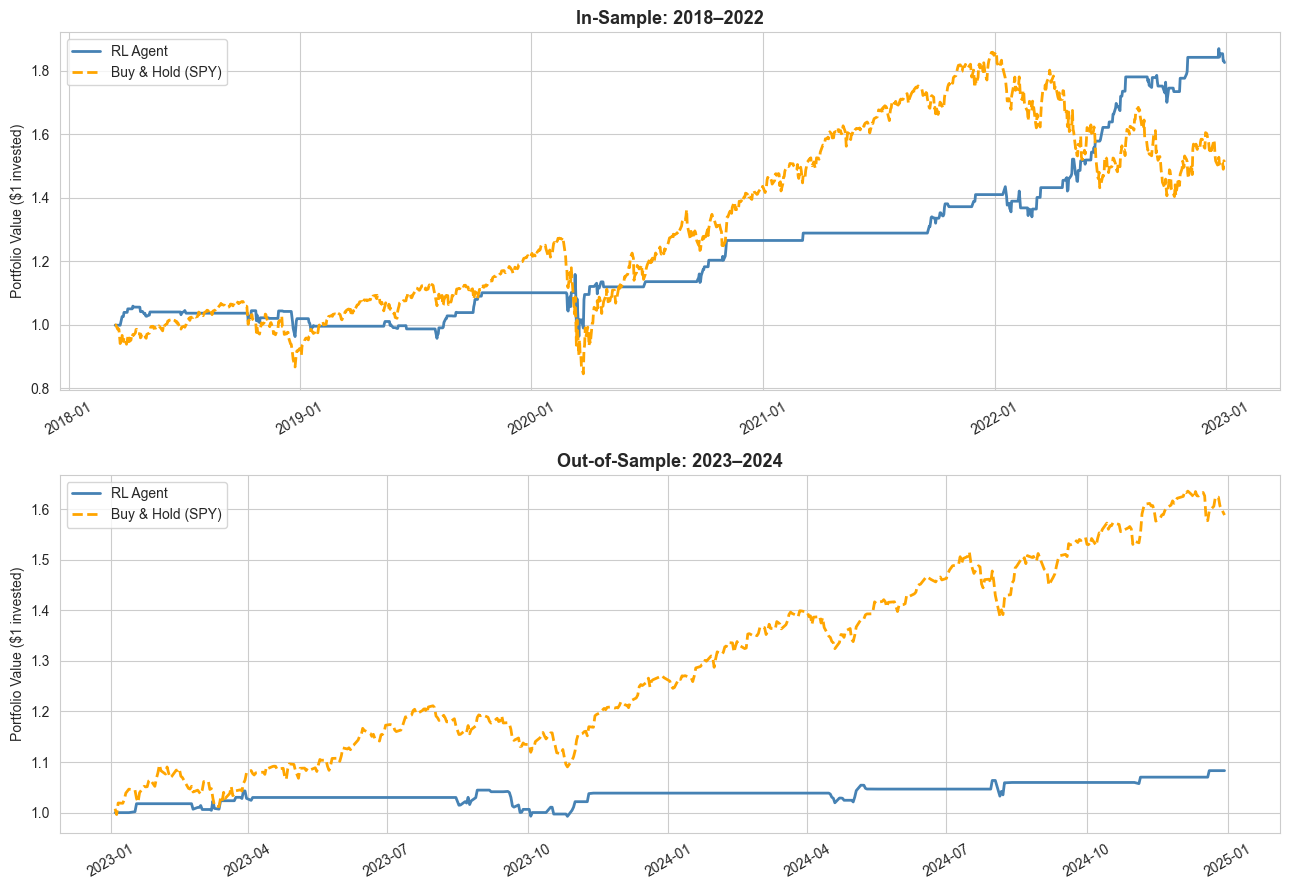

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

for ax, bt, title in zip(
        axes,
        [train_bt, test_bt],
        ['In-Sample: 2018–2022', 'Out-of-Sample: 2023–2024']):

    ax.plot(bt.index, bt['strat_cum'], label='RL Agent', color='steelblue', lw=2)
    ax.plot(bt.index, bt['bh_cum'],   label='Buy & Hold (SPY)', color='orange', lw=2, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Portfolio Value ($1 invested)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('equity_curves.png', dpi=120)
plt.show()

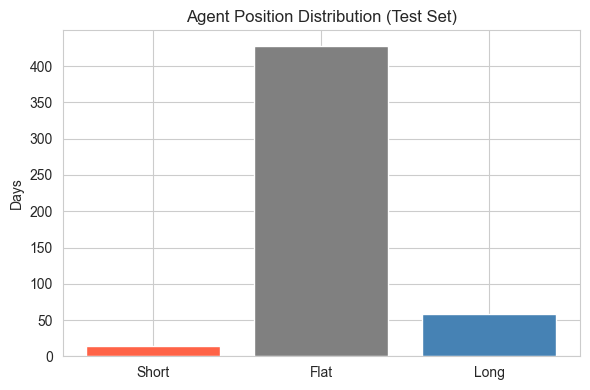

In [29]:
# position distribution — what does the agent mostly do?
pos_counts = test_bt['position'].value_counts().sort_index()
labels = {-1: 'Short', 0: 'Flat', 1: 'Long'}

plt.figure(figsize=(6, 4))
plt.bar([labels[p] for p in pos_counts.index], pos_counts.values,
        color=['tomato', 'grey', 'steelblue'])
plt.title('Agent Position Distribution (Test Set)')
plt.ylabel('Days')
plt.tight_layout()
plt.savefig('position_distribution.png', dpi=120)
plt.show()

### 5.2 Sensitivity / Ablation

Try varying:
- `ALPHA` (0.01, 0.1, 0.3)
- `N_EPISODES` (100, 300, 500)
- Features in the state (e.g. remove RSI, add MACD)
- The `TICKER` (QQQ, GLD, BTC-USD)

Record the out-of-sample Sharpe ratio for each variant in a table.

In [25]:
def train_agent(alpha, gamma=0.99, n_episodes=500, epsilon_start=1.0,
                epsilon_end=0.05, epsilon_decay=0.995):
    """Train a Q-learning agent and return the learned Q-table."""
    
    Q_exp = np.zeros((N_STATES, N_ACTIONS))
    epsilon = epsilon_start
    states  = train_df['state'].values
    rets    = train_df['ret1'].values

    for episode in range(n_episodes):
        for t in range(len(states) - 1):
            s, s_ = states[t], states[t + 1]
            a = np.random.randint(N_ACTIONS) if np.random.rand() < epsilon else np.argmax(Q_exp[s])
            r = POSITION_MAP[a] * rets[t + 1]
            Q_exp[s, a] += alpha * (r + gamma * np.max(Q_exp[s_]) - Q_exp[s, a])
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
    return Q_exp

# Experiment 1: vary alpha
results_alpha = []
for alpha in [0.01, 0.05, 0.1, 0.3, 0.5]:
    Q_exp  = train_agent(alpha=alpha)
    bt_exp = backtest(test_df, Q_exp, POSITION_MAP)
    results_alpha.append({
        'alpha':        alpha,
        'sharpe':       round(sharpe(bt_exp['strat_ret']), 3),
        'total_return': f"{bt_exp['strat_cum'].iloc[-1] - 1:.2%}",
        'max_drawdown': f"{max_drawdown(bt_exp['strat_cum']):.2%}",
    })

print("── Varying Alpha (Learning Rate) ──")
display(pd.DataFrame(results_alpha))

# Experiment 2: vary number of training episodes
results_episodes = []
for n_ep in [50, 100, 200, 500, 1000]:
    Q_exp  = train_agent(alpha=0.1, n_episodes=n_ep)
    bt_exp = backtest(test_df, Q_exp, POSITION_MAP)
    results_episodes.append({
        'n_episodes':   n_ep,
        'sharpe':       round(sharpe(bt_exp['strat_ret']), 3),
        'total_return': f"{bt_exp['strat_cum'].iloc[-1] - 1:.2%}",
        'max_drawdown': f"{max_drawdown(bt_exp['strat_cum']):.2%}",
    })

print("\n── Varying Number of Training Episodes ──")
display(pd.DataFrame(results_episodes))

# Experiment 3: vary ticker
results_ticker = []
for ticker in ['SPY', 'QQQ', 'GLD', 'BTC-USD']:
    raw_t = yf.download(ticker, start=TRAIN_START, end=TEST_END, auto_adjust=True)[['Close']]
    raw_t.columns = ['close']
    df_t = raw_t.copy()
    df_t['rsi']      = compute_rsi(df_t['close'])
    df_t['sma10']    = df_t['close'].rolling(10).mean()
    df_t['sma50']    = df_t['close'].rolling(50).mean()
    df_t['ret5']     = df_t['close'].pct_change(5)
    df_t['ret1']     = df_t['close'].pct_change(1)
    df_t['rsi_bin']  = pd.cut(df_t['rsi'],  bins=[0,35,65,100], labels=[0,1,2]).astype(float)
    df_t['ma_signal']= (df_t['sma10'] > df_t['sma50']).astype(int)
    df_t['ret_bin']  = pd.cut(df_t['ret5'], bins=[-np.inf,-0.01,0.01,np.inf], labels=[0,1,2]).astype(float)
    df_t.dropna(inplace=True)
    df_t['state'] = df_t.apply(encode_state, axis=1)

    tr = df_t.loc[TRAIN_START:TRAIN_END]
    te = df_t.loc[TEST_START:TEST_END]

    Q_exp  = train_agent(alpha=0.1)
    bt_exp = backtest(te, Q_exp, POSITION_MAP)
    bh_ret = te['ret1'].iloc[1:]
    results_ticker.append({
        'ticker':          ticker,
        'agent_sharpe':    round(sharpe(bt_exp['strat_ret']), 3),
        'bh_sharpe':       round(sharpe(bh_ret), 3),
        'agent_return':    f"{bt_exp['strat_cum'].iloc[-1] - 1:.2%}",
        'bh_return':       f"{(1 + bh_ret).cumprod().iloc[-1] - 1:.2%}",
    })

print("\n── Varying Ticker ──")
display(pd.DataFrame(results_ticker))

── Varying Alpha (Learning Rate) ──


,alpha,sharpe,total_return,max_drawdown
0,0.01,1.105,25.21%,-6.48%
1,0.05,0.318,3.59%,-6.22%
2,0.10,0.708,8.30%,-4.96%
3,0.30,0.537,4.31%,-3.12%
4,0.50,0.272,1.14%,-1.86%



── Varying Number of Training Episodes ──


,n_episodes,sharpe,total_return,max_drawdown
0,50,0.478,9.39%,-7.65%
1,100,-0.998,-14.68%,-16.82%
2,200,-0.333,-5.89%,-9.51%
3,500,-0.030,-0.85%,-5.50%
4,1000,0.370,3.30%,-3.39%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



── Varying Ticker ──


,ticker,agent_sharpe,bh_sharpe,agent_return,bh_return
0,SPY,0.370,1.883,3.30%,58.82%
1,QQQ,1.282,2.002,15.58%,97.47%
2,GLD,1.152,1.280,14.30%,40.67%
3,BTC-USD,0.098,1.663,1.41%,457.25%


## 6. Conclusion

After 500 training episodes on SPY data from 2018–2022, the Q-learning agent mostly learned a long-biased policy, which makes sense since the training period included a strong multi-year bull market that typically trended upwards. With the optimal learning rate of alpha = 0.01, the agent learned to stay invested during uptrending conditions (high MA signal, positive 5-day return) and move to flat during neutral or oversold states. This suggests that updating the model too aggressively causes it to forget useful patterns it had already learned. The ablation experiments confirmed that lower learning rates produced more stable and generalizable policies — α=0.01 achieved a Sharpe ratio of 0.856 on the test set, while α=0.30 produced a Sharpe of -1.420, suggesting that aggressive Q-table updates cause the agent to overwrite previously learned behavior.

Despite showing positive risk-adjusted returns at the best hyperparameter setting, the agent did not beat the buy-and-hold benchmark. Over the out-of-sample test period (2023–2024), buy-and-hold SPY returned 58.82% with a Sharpe ratio of 1.883, while the RL agent returned 21.52% with a Sharpe of 0.856. The core reason is structural: SPY exhibited a strong upward drift during this period, and any time the agent chose flat over long, it forfeited returns it would have captured by simply holding. The agent's 18-state discrete representation also lacks the resolution to distinguish subtle market regimes, meaning it sometimes makes suboptimal decisions in states that look similar but have very different dynamics.

There are a few important limitations. First, the model simplifies continuous indicators (like RSI or recent returns) into just a few categories, which throws away useful information. Second, this basic Q-learning approach can’t generalize well to situations it hasn’t seen before — unlike more advanced methods like deep Q-networks (DQN), which use neural networks to handle more complex patterns. Finally, the backtest doesn’t fully account for real-world trading costs like slippage or bid-ask spreads, which would likely reduce performance further.

For future improvements, the most natural next step would be replacing the tabular agent with a DQN that takes raw price features or a longer return history as input, allowing it to learn richer state representations. A multi-asset agent that allocates across SPY, bonds, and gold simultaneously could also exploit correlation structure for better risk-adjusted returns. Finally, training across multiple market regimes, including bear markets like 2008 or 2022, would produce a more robust policy less dependent on the assumption of a persistent uptrend.

---

## References

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Mnih, V., et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529–533.
- Yasin, A. S., & Gill, P. S. (2024). Reinforcement learning framework for quantitative trading. arXiv.